In [ ]:
import os
import glob
import gzip
import scipy.io

import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
####################### barcodes ranks // coloured as ordered estrho

In [ ]:
# func for looking and loading data from cellranger
def load_barcode_counts(matrix_dir):
    # matrix
    matrix = scipy.io.mmread(os.path.join(matrix_dir, "matrix.mtx.gz")).tocsc()

    # barcodes
    with gzip.open(os.path.join(matrix_dir, "barcodes.tsv.gz"), "rt") as f:
        barcodes = [line.strip() for line in f]

    # total umis per barcode
    umi_counts = np.array(matrix.sum(axis=0)).flatten()
    df = pd.DataFrame({
        "barcode": barcodes,
        "total_umis": umi_counts
    })

    # assigning rank based on umis counts -descending
    df = df[df["total_umis"] > 0]
    df["rank"] = df["total_umis"].rank(ascending=False, method="first")
    df.sort_values("rank", inplace=True)
    return df

In [ ]:
# cellranger with unfiltered folder
base_dir = "../../data/cellranger"

# output for barcode ranks
rank_data_dir = "../rank_data"
os.makedirs(rank_data_dir, exist_ok=True)

In [ ]:
# all raw_feature_bc_matrix directories
matrix_dirs = []
for root, dirs, files in os.walk(base_dir):
    if "raw_feature_bc_matrix" in root and "matrix.mtx.gz" in files:
        matrix_dirs.append(root)

In [9]:
len(matrix_dirs)

35

In [ ]:
# wasnt so heavy after all <3
for root, dirs, files in os.walk(base_dir):
    if "raw_feature_bc_matrix" in root and "matrix.mtx.gz" in files:
        sample_name = os.path.basename(os.path.dirname(os.path.dirname(root)))
        try:
            df = load_barcode_counts(root)
            df.to_csv(os.path.join(output_dir, f"{sample_name}_rank.csv"), index=False)
            print(f"✅ Saved rank data for {sample_name}")
        except Exception as e:
            print(f"⚠️ Failed for {sample_name}: {e}")

✅ Saved rank data for GC1001331_B3
✅ Saved rank data for GC1002817_E6
✅ Saved rank data for GC1001405_H3
✅ Saved rank data for GC1001330_A3
✅ Saved rank data for GC090246_A2
✅ Saved rank data for GC088248_G1
✅ Saved rank data for GC117077_SI-GA-B8
✅ Saved rank data for GC117090_SI-GA-C8
✅ Saved rank data for GC1001407_E3
✅ Saved rank data for GC1001790_C4
✅ Saved rank data for GC088249_H1
✅ Saved rank data for GC1002818_F6
✅ Saved rank data for GC1001791_D4
✅ Saved rank data for GC092332_F2
✅ Saved rank data for GC087836_E1
✅ Saved rank data for GC117076_SI-GA-A8
✅ Saved rank data for GC1001332_C3
✅ Saved rank data for GC117918_SI-GA-C4
✅ Saved rank data for GC1001408_F3
✅ Saved rank data for GC092331_E2
✅ Saved rank data for GC1001789_B4
✅ Saved rank data for GC117917_SI-GA-B4
✅ Saved rank data for GC092577_G2
✅ Saved rank data for GC117919_SI-GA-D4
✅ Saved rank data for GC1001807_G4
✅ Saved rank data for GC117091_SI-GA-D8
✅ Saved rank data for GC1001805_E4
✅ Saved rank data for GC100

In [ ]:
#################################### filtered

In [ ]:
# mark the filtered out barcodes for each sample

def load_filtered_barcodes(filtered_dir):
    barcodes_path = os.path.join(filtered_dir, "barcodes.tsv.gz")
    if not os.path.exists(barcodes_path):
        return set()
    with gzip.open(barcodes_path, "rt") as f:
        return set(line.strip() for line in f)

In [ ]:
rank_dir = "../rank_data"
out_dir = "../rank_data_filter"
os.makedirs(out_dir, exist_ok=True)

In [29]:
for filepath in glob.glob(os.path.join(rank_dir, "*_rank.csv")):
    sample_name = os.path.basename(filepath).replace("_rank.csv", "")
    df = pd.read_csv(filepath)

    if df.empty or "barcode" not in df.columns:
        continue

    filtered_dir = os.path.join("..", "out", sample_name, "outs", "filtered_feature_bc_matrix")
    filtered_barcodes = load_filtered_barcodes(filtered_dir)

    df["is_cell"] = df["barcode"].isin(filtered_barcodes)
    df.to_csv(os.path.join(out_dir, f"{sample_name}_rank_filtered.csv"), index=False)
    print(f"✅ Saved {sample_name} with filter info")

✅ Saved GC092332_F2 with filter info
✅ Saved GC117075_SI-GA-H7 with filter info
✅ Saved GC1002817_E6 with filter info
✅ Saved GC1001791_D4 with filter info
✅ Saved GC1001331_B3 with filter info
✅ Saved GC088247_F1 with filter info
✅ Saved GC092330_D2 with filter info
✅ Saved GC1001332_C3 with filter info
✅ Saved GC117917_SI-GA-B4 with filter info
✅ Saved GC1002818_F6 with filter info
✅ Saved GC1001408_F3 with filter info
✅ Saved GC1001405_H3 with filter info
✅ Saved GC117918_SI-GA-C4 with filter info
✅ Saved GC1001407_E3 with filter info
✅ Saved GC1001807_G4 with filter info
✅ Saved GC117091_SI-GA-D8 with filter info
✅ Saved GC1001406_D3 with filter info
✅ Saved GC088249_H1 with filter info
✅ Saved GC1001789_B4 with filter info
✅ Saved GC1001328_H2 with filter info
✅ Saved GC092331_E2 with filter info
✅ Saved GC1002819_G6 with filter info
✅ Saved GC092577_G2 with filter info
✅ Saved GC087836_E1 with filter info
✅ Saved GC1001805_E4 with filter info
✅ Saved GC1001330_A3 with filter info

In [ ]:
#################### color the samples based on ambientRNA removal rho

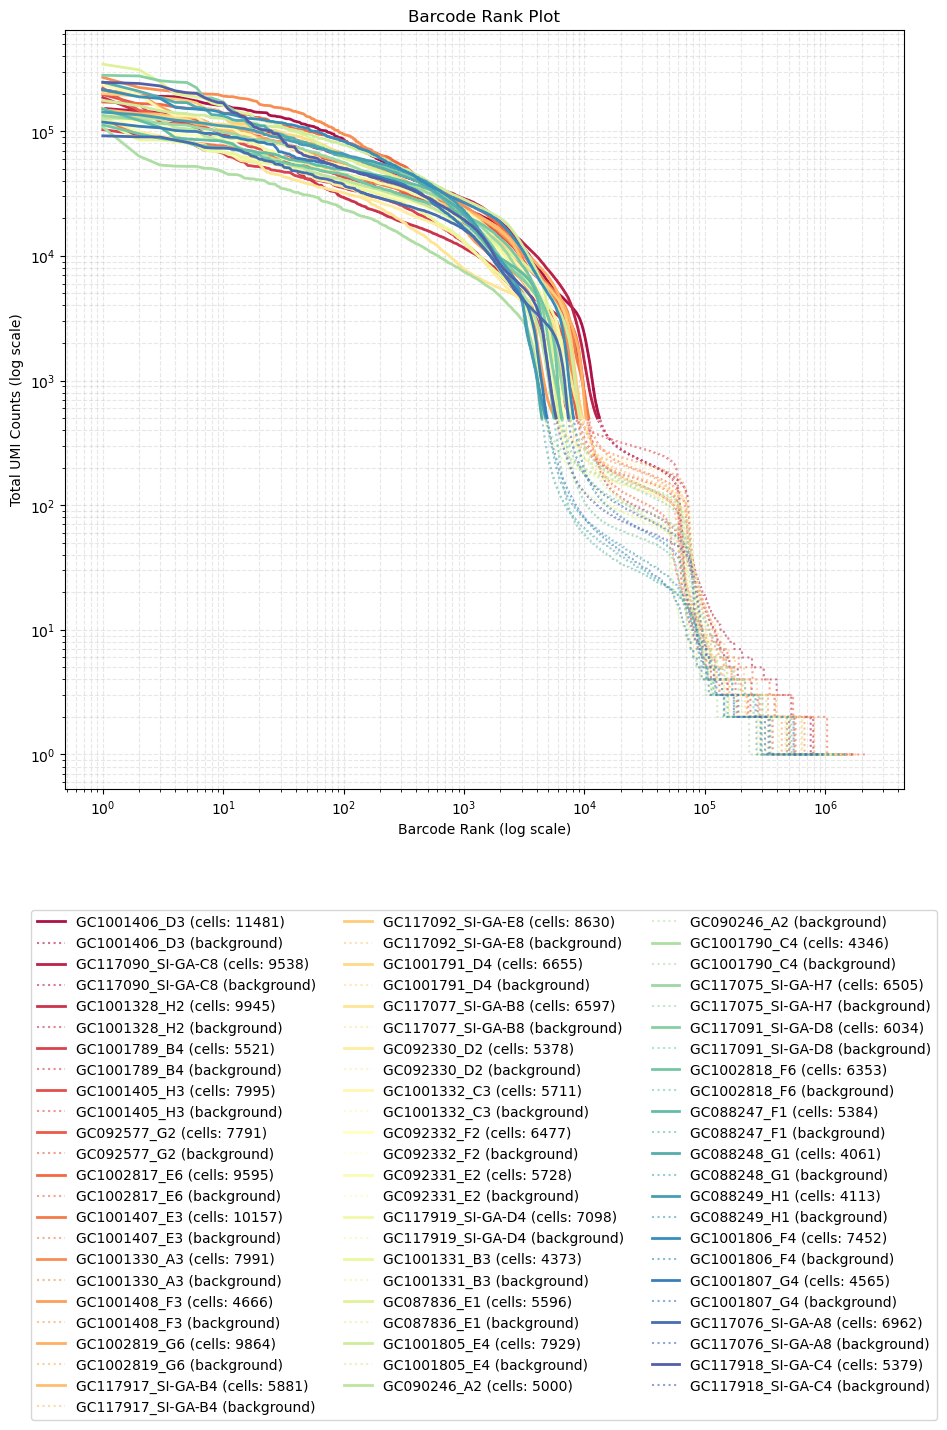

In [ ]:
# load color sample order
order_df = pd.read_csv("samples_ordered.csv")  # contains columns: Sample, estRho
ordered_samples = order_df["Sample"].tolist()

# colors
n_samples = len(ordered_samples)
colors = sns.color_palette("Spectral", n_colors=n_samples)
color_dict = dict(zip(ordered_samples, colors))

# plot
filtered_dir = "../rank_data_filter"
plt.figure(figsize=(10, 15))

for sample_name in ordered_samples:
    filepath = os.path.join(filtered_dir, f"{sample_name}_rank_filtered.csv")
    if not os.path.exists(filepath):
        print(f"⚠️ Missing file: {filepath}")
        continue

    df = pd.read_csv(filepath)

    num_cells = df["is_cell"].sum()
    df_filtered = df[df["is_cell"] == True]
    df_unfiltered = df[df["is_cell"] == False]

    color = color_dict[sample_name]

    # cells solid line
    plt.plot(df_filtered["rank"], df_filtered["total_umis"],
             label=f"{sample_name} (cells: {num_cells})",
             color=color, linewidth=2)

    # empty droplets background dotted line
    plt.plot(df_unfiltered["rank"], df_unfiltered["total_umis"],
             label=f"{sample_name} (background)",
             color=color, linestyle="dotted", alpha=0.6)

# styling
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Barcode Rank (log scale)")
plt.ylabel("Total UMI Counts (log scale)")
plt.title("Barcode Rank Plot")

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, fancybox=True)
plt.grid(True, which="both", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.savefig("../plots/barcode_rank_with_filter_ordered.png", dpi=300, bbox_inches="tight")
plt.show()